In [1]:
def add(a:int,b:int)->int:
    """ Docstring for add
    
    :param a: Description
    :type a: int
    :param b: Description
    :type b: int
    :return: Description
    :rtype: int"""

    return a+b

In [3]:
from typing import Annotated
from typing_extensions import TypedDict
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages
from langchain_core.messages import HumanMessage,AIMessage,AnyMessage
from IPython.display import Image,display
from langgraph.prebuilt import ToolNode,tools_condition

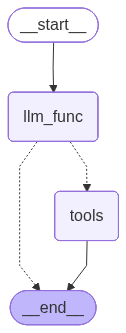

In [4]:
class State(TypedDict):
    messages : Annotated[list[AnyMessage],add_messages]

llm = ChatOpenAI(model="gpt-4o-mini")

tools = [add]

llm_tools = llm.bind_tools(tools=tools)

initial_message = [AIMessage(content="How can I help you",name="llmmodel")]
initial_message.append(HumanMessage(content="I want to learn programming",name="Harika"))

ai_message = AIMessage(content="Which PL you want to learn",name='llmmodel')

add_messages(initial_message,ai_message)

def llm_func(state:State):
    return {"messages":[llm_tools.invoke(state['messages'])]}


builder = StateGraph(State)

builder.add_node('llm_func',llm_func)
builder.add_node('tools',ToolNode(tools))
builder.add_edge(START,'llm_func')
builder.add_conditional_edges('llm_func',#If the latest message (result) from assistant is a tool call->tool_condition routes to tools
                              # If the latest message (result) from assistant is not a tool call->tool_condition routes to END
                              tools_condition)

builder.add_edge('tools',END)

graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [5]:
from langchain_core.messages import HumanMessage

messages = graph.invoke({"messages":"What is 2+2"})
for message in messages['messages']:
    message.pretty_print()

================================ Human Message =================================

What is 2+2
================================== Ai Message ==================================
Tool Calls:
  add (call_pfJDiOqLrymepOrrawyIjZFB)
 Call ID: call_pfJDiOqLrymepOrrawyIjZFB
  Args:
    a: 2
    b: 2
================================= Tool Message =================================
Name: add

4
